#### https://seaborn.pydata.org/examples/index.html

In [182]:
# Fatal Police Shootings in the US

# INTRODUCTION
1. Read datas 
1. Poverty rate of each state ( Her eyaletteki fakirlik oranı nedir)
1. Most common 15 Name or Surname of killed people ( öldürülen isimlerden en çok kullanılanlar)
1. High school graduation rate of the population that is older than 25 in states ( 25 yaşından büyük insanların  liseden mezun olma oranı)
1. Percentage of state's population according to races that are black,white,native american, asian and hispanic
1. High school graduation rate vs Poverty rate of each state
1. Kill properties
    * Manner of death
    * Kill weapon
    * Age of killed people
    * Race of killed people
    * Most dangerous cities
    * Most dangerous states
    * Having mental ilness or not for killed people
    * Threat types
    * Flee types
    * Having body cameras or not for police
1. Race rates according to states in kill data 
1. Kill numbers from states in kill data
<br>
<br>
Plot Contents:
* [Bar Plot]
* [Point Plot]
* [Joint Plot]
* [Pie Chart]
* [Lm Plot]
* [Kde Plot]
* [Violin Plot]
* [Heatmap]
* [Box Plot]
* [Swarm Plot]
* [Pair Plot]
* [Count Plot]

- Bir data ve bu data ile ilgili sorular var . EDA yapıyoruz.

In [184]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore') 

In [185]:
# Veriseti 5 farklı datadan oluşuyor 

In [186]:
# Read datas
median_house_hold_in_come = pd.read_csv('Seaborn/MedianHouseholdIncome2015.csv', encoding="windows-1252")
percentage_people_below_poverty_level = pd.read_csv('Seaborn/PercentagePeopleBelowPovertyLevel.csv', encoding="windows-1252")
percent_over_25_completed_highSchool = pd.read_csv('Seaborn/PercentOver25CompletedHighSchool.csv', encoding="windows-1252")
kill = pd.read_csv('Seaborn/PoliceKillingsUS.csv', encoding="windows-1252")
share_race_city = pd.read_csv('Seaborn/ShareRaceByCity.csv', encoding="windows-1252")
#datasetlerini oluşturduk

In [187]:
# ilk sorumuz : bir eyaletin fakirlik oranı

In [188]:
percentage_people_below_poverty_level.head()

,Geographic Area,City,poverty_rate
0,AL,Abanda CDP,78.8
1,AL,Abbeville city,29.1
2,AL,Adamsville city,25.5
3,AL,Addison town,30.7
4,AL,Akron town,42


In [189]:
# Geographic Area : Eyalet -----  poverty_rate = fakirlik oranı 

In [190]:
percentage_people_below_poverty_level.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29329 entries, 0 to 29328
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Geographic Area  29329 non-null  object
 1   City             29329 non-null  object
 2   poverty_rate     29329 non-null  object
dtypes: object(3)
memory usage: 687.5+ KB


In [191]:
#poverty_rate değişkeniini floata convert edicez.

In [192]:
percentage_people_below_poverty_level.poverty_rate.value_counts()


poverty_rate
0       1464
-        201
7.4      129
6.7      129
10.9     128
        ... 
73.5       1
92         1
73.8       1
55.9       1
83.6       1
Name: count, Length: 771, dtype: int64

In [193]:
# Fakirlik oranı 0 olan 1464 yer var.
# - işareti olan 201 data var. Onları görmezden gelmek zorundayız.

In [194]:
percentage_people_below_poverty_level['Geographic Area'].unique() 
# eyaletleri al bunun içinde unique değerleri bul

array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA',
       'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA',
       'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY',
       'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
       'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY'], dtype=object)

In [195]:
len(percentage_people_below_poverty_level['Geographic Area'].unique()) 


51

## Bar Plot

In [197]:
# Poverty rate of each state
percentage_people_below_poverty_level.poverty_rate.replace(['-'],0.0,inplace = True) # - olanı 0 ile değiştirip soldaki değişkene atıyorum yeni halini.
percentage_people_below_poverty_level.poverty_rate = percentage_people_below_poverty_level.poverty_rate.astype(float) # object to float
area_list = list(percentage_people_below_poverty_level['Geographic Area'].unique()) # her bir eyaletin fakirlik oranı bunun için unique değerleri  bulmamız lazım.
area_poverty_ratio = []
# Sıralama için burda ortalama buluyoruz.
# Fakirik oranı büyükten küçüğe olacak şekilde sıraladık.
for i in area_list:
    x = percentage_people_below_poverty_level[percentage_people_below_poverty_level['Geographic Area']==i]
    area_poverty_rate = sum(x.poverty_rate)/len(x)
    area_poverty_ratio.append(area_poverty_rate)


data = pd.DataFrame({'area_list': area_list,'area_poverty_ratio':area_poverty_ratio})

# ascending false ile azalan sırada yapıyoruz.
new_index = (data['area_poverty_ratio'].sort_values(ascending=False)).index.values


sorted_data = data.reindex(new_index)


In [198]:
#datamızı sıralamaya sokacağız

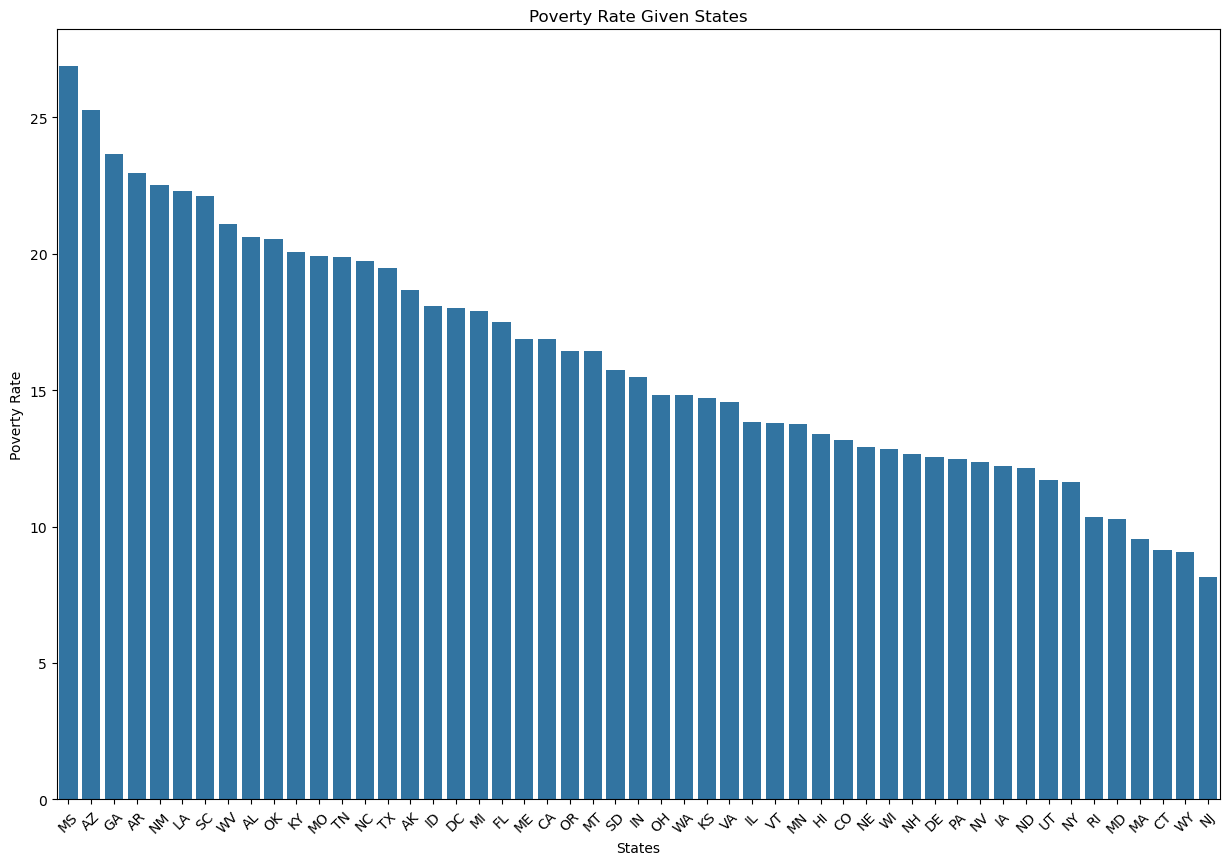

In [199]:
# visualization

# 15 genişlik 10 uzunluk
plt.figure(figsize=(15,10))
sns.barplot(x=sorted_data['area_list'], y=sorted_data['area_poverty_ratio'])
#  eyalet adlarını 45 derecelik  açı ile koyduk
plt.xticks(rotation= 45)
plt.xlabel('States')
plt.ylabel('Poverty Rate')
plt.title('Poverty Rate Given States')
plt.show()

In [200]:
# Soru 2 Öldürülen insanların kullanılan isimleri ve soyisimleri içindeki en çok kullanılan 15 tanesini bul

In [201]:
# kill  datası kullanılacak bu soru için 
kill.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [202]:
# sorunlu data var mı yok mu bakmak lazım
kill.name.value_counts()

name
TK TK              49
Michael Johnson     2
Brandon Jones       2
Eric Harris         2
Michael Brown       2
                   ..
Jack Yantis         1
James Covington     1
Jeremy Mardis       1
Joseph Tyndall      1
Dwayne Jeune        1
Name: count, Length: 2481, dtype: int64

In [203]:
# TK TK sorunlu data polisler ismini bulamadı muhtemelen

In [204]:
["ali", "haydar"]

['ali', 'haydar']

In [205]:
# Most common 15 Name or Surname of killed people
separate = kill.name[kill.name != 'TK TK'].str.split() # TK TK olmayanları al stringe çevir ve boşluğa göre split yap yani ayır.
a,b = zip(*separate)  # unzip ile isim ve soyisim parametresi isim ve soyisim ayrılır.                  
name_list = a+b      # bir tuple içinde birleşiyor                   
name_count = Counter(name_list)    # hepsini  sayar neyden kaç tane var diye     
most_common_names = name_count.most_common(15)  #en çok 15 tane olanı hesapla
x,y = zip(*most_common_names)
x,y = list(x),list(y)


In [206]:
#a


In [207]:
#b


In [208]:
#a+b # bir tuple içinde birleşiyor

In [209]:
name_count

Counter({'Michael': 91,
         'David': 57,
         'James': 56,
         'Robert': 48,
         'Joseph': 48,
         'William': 47,
         'Daniel': 46,
         'John': 42,
         'Christopher': 40,
         'Lee': 37,
         'Richard': 36,
         'J.': 32,
         'Anthony': 31,
         'Jose': 28,
         'Joshua': 28,
         'Charles': 27,
         'Thomas': 26,
         'Jason': 25,
         'Matthew': 24,
         'Scott': 23,
         'Mark': 22,
         'Smith': 22,
         'Allen': 21,
         'Andrew': 20,
         'Brandon': 20,
         'Johnson': 20,
         'Kenneth': 19,
         'Paul': 19,
         'Edward': 19,
         'Jeffrey': 18,
         'A.': 18,
         'M.': 18,
         'Eric': 17,
         'Ryan': 16,
         'Kevin': 16,
         'Ray': 15,
         'D.': 15,
         'L.': 15,
         'Jeremy': 14,
         'Antonio': 14,
         'Angel': 14,
         'Steven': 14,
         'Keith': 14,
         'Patrick': 13,
         'Nicholas

In [210]:
most_common_names

[('Michael', 91),
 ('David', 57),
 ('James', 56),
 ('Robert', 48),
 ('Joseph', 48),
 ('William', 47),
 ('Daniel', 46),
 ('John', 42),
 ('Christopher', 40),
 ('Lee', 37),
 ('Richard', 36),
 ('J.', 32),
 ('Anthony', 31),
 ('Jose', 28),
 ('Joshua', 28)]

In [211]:
#x,y = zip(*most_common_names)

In [212]:
#x,y = list(x),list(y)

In [213]:
#x

In [214]:
#y

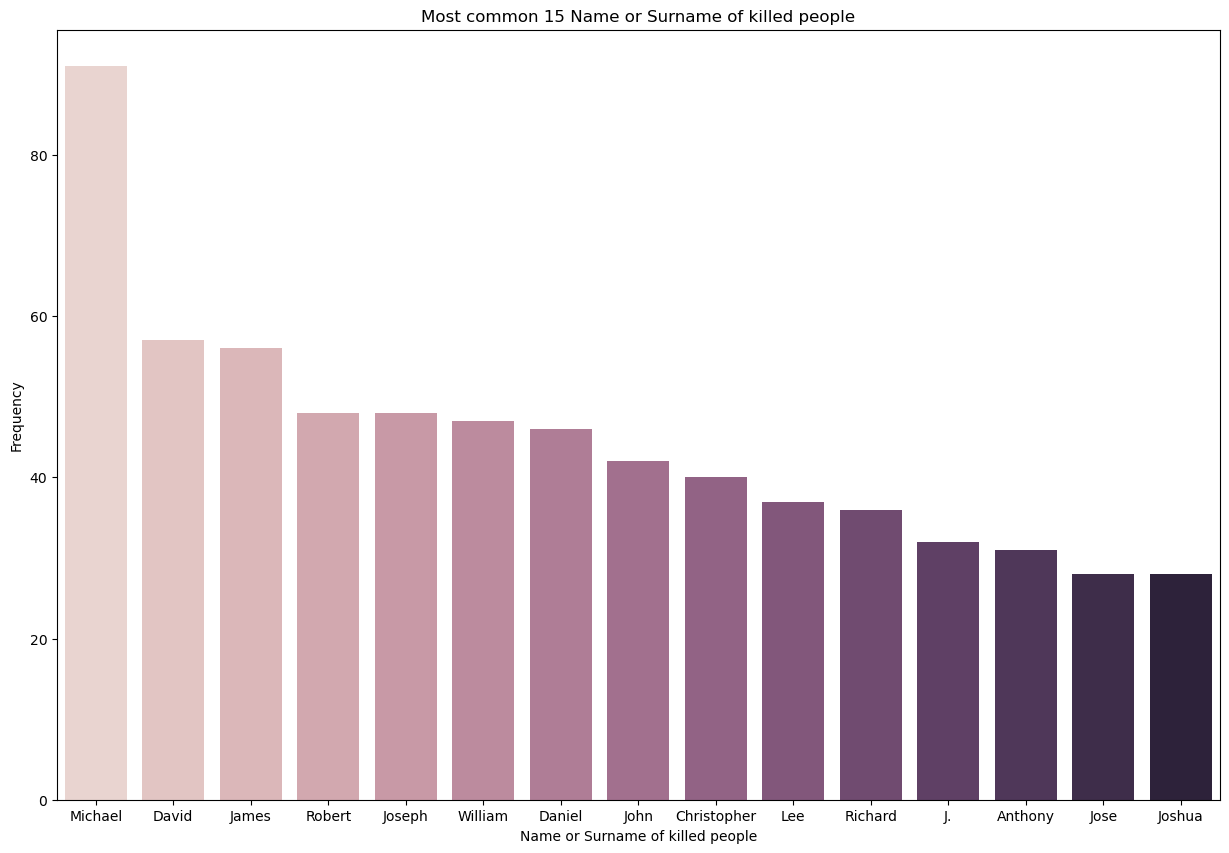

In [215]:
# 
plt.figure(figsize=(15,10))
#palette : farklı renkl tonlarını ifade ediyor. len x mantığı ile bu uzunluk sayısı kadar birbiri ile uyumlu farklı renk  verir.
ax = sns.barplot(x=x, y=y,palette = sns.cubehelix_palette(len(x)))
plt.xlabel('Name or Surname of killed people')
plt.ylabel('Frequency')
plt.title('Most common 15 Name or Surname of killed people')
plt.show()

In [216]:
# soru 3 ---- 25  yaşından büyük insanların liseden mezun olma oranı 

In [217]:
percent_over_25_completed_highSchool.head()
# highschool -gradued ratio

,Geographic Area,City,percent_completed_hs
0,AL,Abanda CDP,21.2
1,AL,Abbeville city,69.1
2,AL,Adamsville city,78.9
3,AL,Addison town,81.4
4,AL,Akron town,68.6


In [218]:
percent_over_25_completed_highSchool.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29329 entries, 0 to 29328
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Geographic Area       29329 non-null  object
 1   City                  29329 non-null  object
 2   percent_completed_hs  29329 non-null  object
dtypes: object(3)
memory usage: 687.5+ KB


In [219]:
# percent_completed_hs  object to float

In [220]:
percent_over_25_completed_highSchool.percent_completed_hs.value_counts()

percent_completed_hs
100     1301
-        197
91.7     170
92.9     169
92.5     168
        ... 
39.3       1
20.1       1
27.2       1
36.8       1
43.9       1
Name: count, Length: 728, dtype: int64

In [221]:
# 197 tane bilinmeyen değeri 0  işe değiştircez

In [222]:
# High school graduation rate of the population that is older than 25 in states
percent_over_25_completed_highSchool.percent_completed_hs.replace(['-'],0.0,inplace = True)
percent_over_25_completed_highSchool.percent_completed_hs = percent_over_25_completed_highSchool.percent_completed_hs.astype(float)
area_list = list(percent_over_25_completed_highSchool['Geographic Area'].unique())
# datayı düzenledik


area_highschool = []
for i in area_list:
    x = percent_over_25_completed_highSchool[percent_over_25_completed_highSchool['Geographic Area']==i]
    area_highschool_rate = sum(x.percent_completed_hs)/len(x)
    area_highschool.append(area_highschool_rate)

# sıralama ascending true ile artana göre olarak ayarlandı

# sorting
data = pd.DataFrame({'area_list': area_list,'area_highschool_ratio':area_highschool})
#sırala ve sıralamanın indexini bul
new_index = (data['area_highschool_ratio'].sort_values(ascending=True)).index.values
sorted_data2 = data.reindex(new_index)

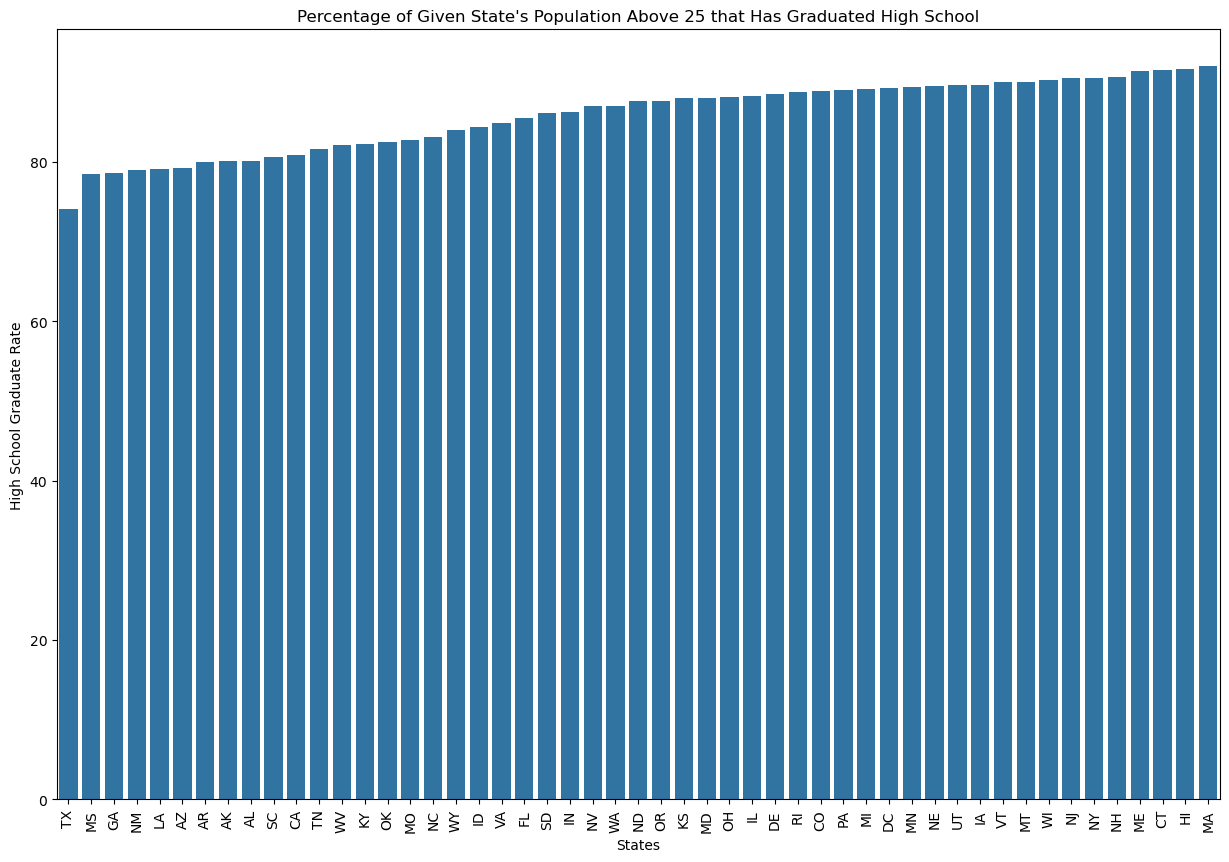

In [223]:
# visualization
plt.figure(figsize=(15,10))
sns.barplot(x=sorted_data2['area_list'], y=sorted_data2['area_highschool_ratio'])
plt.xticks(rotation= 90)
plt.xlabel('States')
plt.ylabel('High School Graduate Rate')
plt.title("Percentage of Given State's Population Above 25 that Has Graduated High School")
plt.show()

In [224]:
# Soru 4 Eyaletlerdeki ırkların oranını görselleştir.

In [225]:
share_race_city.head()
# Bu oranlar şehirlere göre biz eyaletlere göre biliyoruz.

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AL,Abanda CDP,67.2,30.2,0,0,1.6
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3
3,AL,Addison town,99.1,0.1,0,0.1,0.4
4,AL,Akron town,13.2,86.5,0,0,0.3


In [226]:
share_race_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29268 entries, 0 to 29267
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Geographic area        29268 non-null  object
 1   City                   29268 non-null  object
 2   share_white            29268 non-null  object
 3   share_black            29268 non-null  object
 4   share_native_american  29268 non-null  object
 5   share_asian            29268 non-null  object
 6   share_hispanic         29268 non-null  object
dtypes: object(7)
memory usage: 1.6+ MB


In [227]:
# Percentage of state's population according to races that are black,white,native american, asian and hispanic
share_race_city.replace(['-'],0.0,inplace = True)
share_race_city.replace(['(X)'],0.0,inplace = True)
share_race_city.loc[:,['share_white','share_black','share_native_american','share_asian','share_hispanic']] = share_race_city.loc[:,['share_white','share_black','share_native_american','share_asian','share_hispanic']].astype(float)
area_list = list(share_race_city['Geographic area'].unique())

In [228]:
share_white = []
share_black = []
share_native_american = []
share_asian = []
share_hispanic = []
for i in area_list:
    x = share_race_city[share_race_city['Geographic area']==i]
    share_white.append(sum(x.share_white)/len(x))
    share_black.append(sum(x.share_black) / len(x))
    share_native_american.append(sum(x.share_native_american) / len(x))
    share_asian.append(sum(x.share_asian) / len(x))
    share_hispanic.append(sum(x.share_hispanic) / len(x))

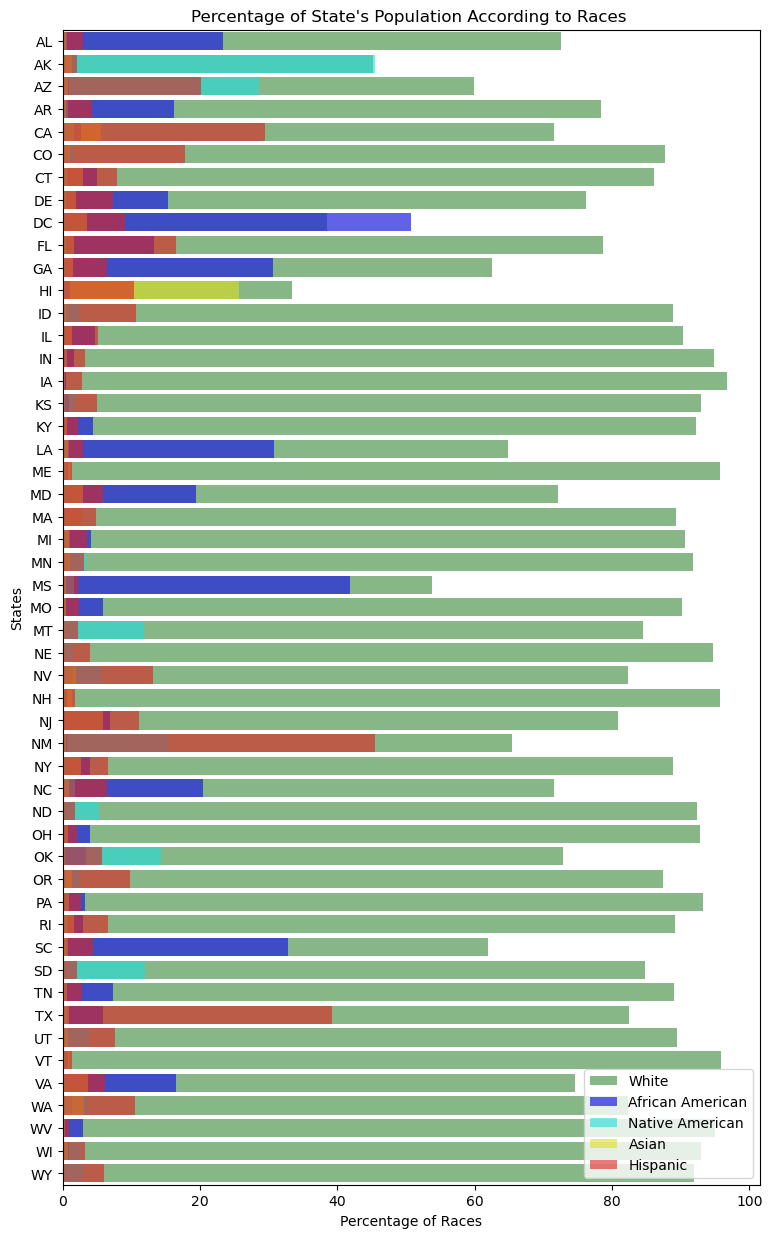

In [229]:
# visualization
f,ax = plt.subplots(figsize = (9,15))
sns.barplot(x=share_white,y=area_list,color='green',alpha = 0.5,label='White' )
sns.barplot(x=share_black,y=area_list,color='blue',alpha = 0.7,label='African American')
sns.barplot(x=share_native_american,y=area_list,color='cyan',alpha = 0.6,label='Native American')
sns.barplot(x=share_asian,y=area_list,color='yellow',alpha = 0.6,label='Asian')
sns.barplot(x=share_hispanic,y=area_list,color='red',alpha = 0.6,label='Hispanic')

ax.legend(loc='lower right',frameon = True)     # legendlarin gorunurlugu
ax.set(xlabel='Percentage of Races', ylabel='States',title = "Percentage of State's Population According to Races ")
plt.show()

## Point Plot

In [231]:
# Soru 5 lise mezuniyet oranı vs her eyaletin yoksulluk oranı

In [232]:
sorted_data.head()

,area_list,area_poverty_ratio
24,MS,26.884254
2,AZ,25.268071
10,GA,23.663636
3,AR,22.963216
31,NM,22.507675


In [233]:
sorted_data2.head() 

,area_list,area_highschool_ratio
43,TX,74.086949
24,MS,78.470718
10,GA,78.634450
31,NM,78.971783
18,LA,79.122363


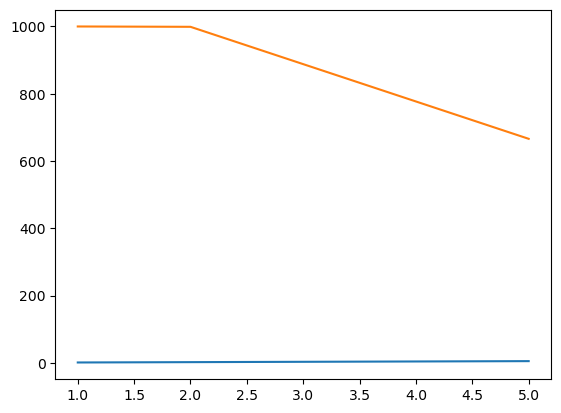

In [234]:
#[1,2,3,4,5]  [1000,999,998,997,996]
# bu iki datayı karşılaştırıp görselleştirmek istiyorum.Biri 1000lerde 
#biri 1 lerde onun için normalizasyon yapıcaz

x1 = [ 1,2,3,4,5]
y1 = [1,2,3,4,5]
y2= [1000,999,888,777,666]
plt.plot(x1,y1)
plt.plot(x1,y2)

In [235]:
# mavi datadaki fark ayırt edilemez
# 0 ile 1 arasına normalize etmek bunun  için öenmli
#0<[1,2,3,4,5]/5<1
#0<[1000,999,888,777,666]/5<1 # basit bir norm . tekniği

In [236]:
#liseden mezun olma fakirlik oranını etkliyor mu onu görmek istiyoruz

In [237]:
# high school graduation rate vs Poverty rate of each state
# normalize etme işlemleri
sorted_data['area_poverty_ratio'] = sorted_data['area_poverty_ratio']/max( sorted_data['area_poverty_ratio'])
sorted_data2['area_highschool_ratio'] = sorted_data2['area_highschool_ratio']/max( sorted_data2['area_highschool_ratio'])
# dataları birleştirme ve sıralama
data = pd.concat([sorted_data,sorted_data2['area_highschool_ratio']],axis=1)
data.sort_values('area_poverty_ratio',inplace=True)

In [238]:
data.head() # 0-1 arasına geldi data

,area_list,area_poverty_ratio,area_highschool_ratio
30,NJ,0.303558,0.983615
50,WY,0.337139,0.912479
6,CT,0.339883,0.995254
21,MA,0.355090,1.000000
20,MD,0.382097,0.957107


In [239]:
data.columns

Index(['area_list', 'area_poverty_ratio', 'area_highschool_ratio'], dtype='object')

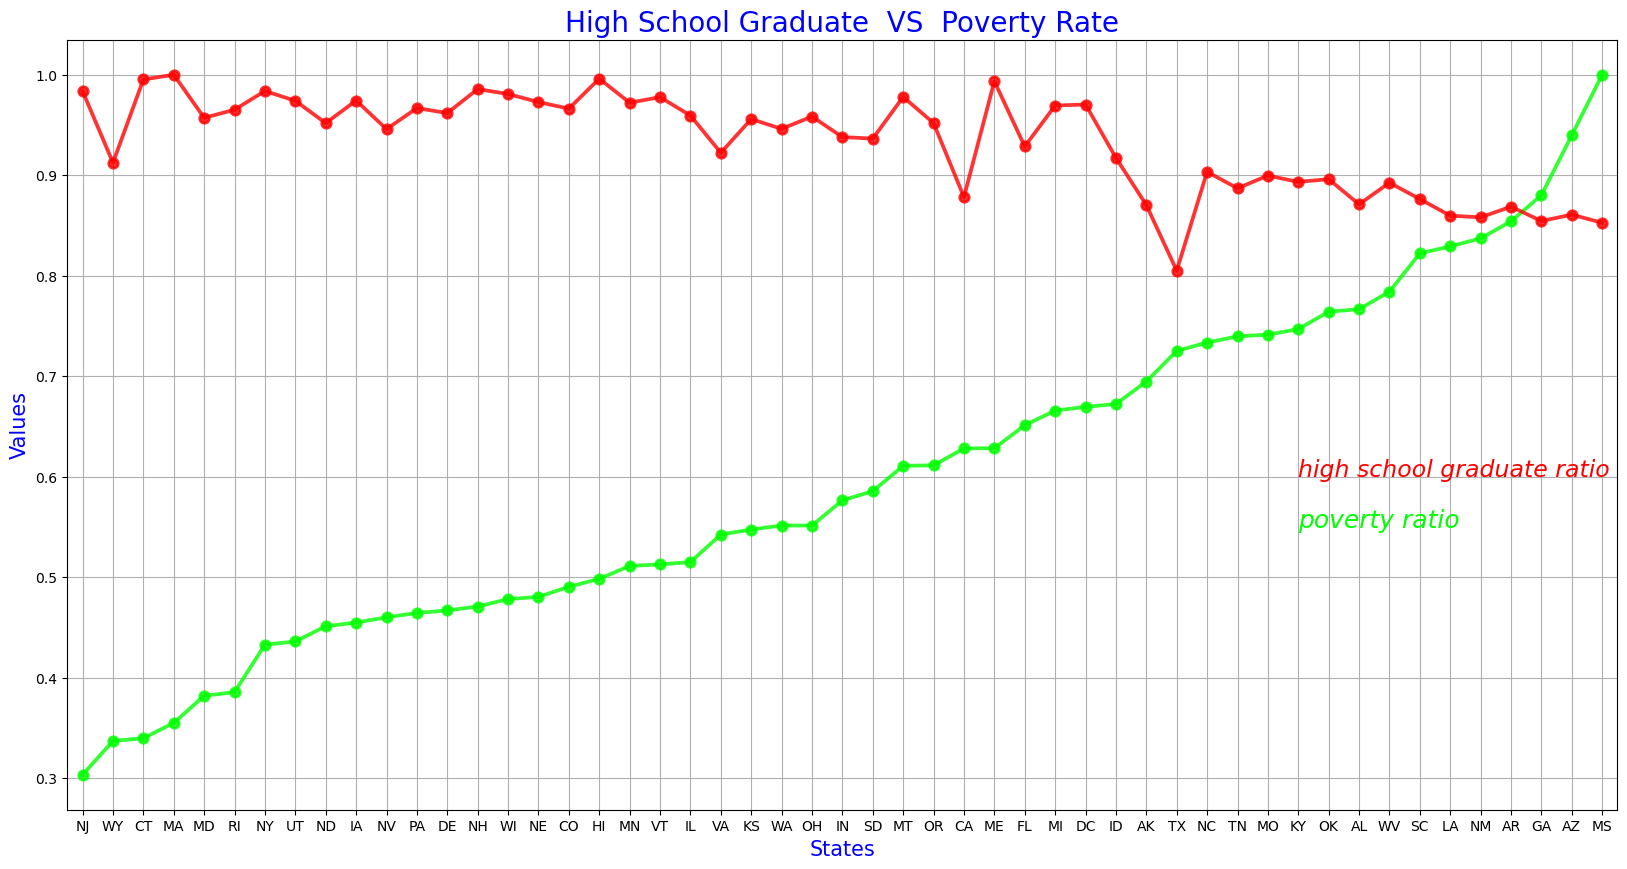

In [240]:
# visualize
f,ax1 = plt.subplots(figsize =(20,10))
sns.pointplot(x='area_list',y='area_poverty_ratio',data=data,color='lime',alpha=0.8) # data vererek seaborn anlar columnları  #seaborn
sns.pointplot(x='area_list',y='area_highschool_ratio',data=data,color='red',alpha=0.8)  #seaborn

plt.text(40,0.6,'high school graduate ratio',color='red',fontsize = 17,style = 'italic') # 40 : x deki konum 0.6 : y deki konum  #matplotlib
plt.text(40,0.55,'poverty ratio',color='lime',fontsize = 18,style = 'italic') #matplotlib
plt.xlabel('States',fontsize = 15,color='blue') #matplotlib
plt.ylabel('Values',fontsize = 15,color='blue') #matplotlib
plt.title('High School Graduate  VS  Poverty Rate',fontsize = 20,color='blue') #matplotlib
plt.grid() #matplotlib 

In [241]:
# bu ikisinin ters orantılı olduğu görülür.

## Joint Plot

In [243]:
# high school graduation rate vs Poverty rate

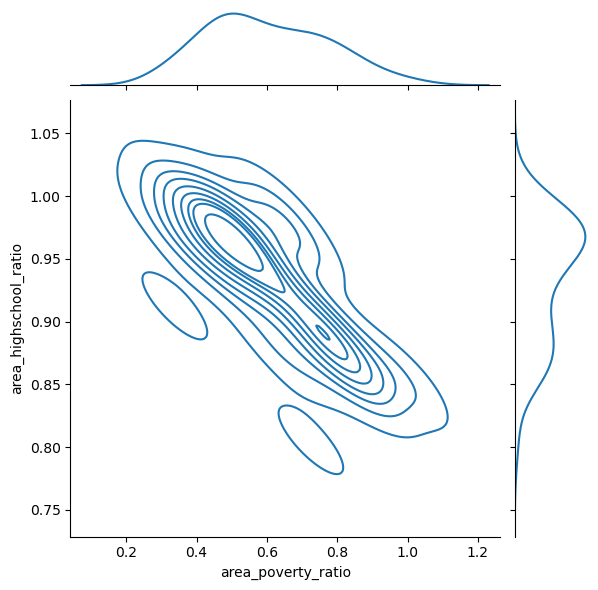

In [249]:
# Visualization of high school graduation rate vs Poverty rate of each state with different style of seaborn code
# joint kernel density
# pearsonr= if it is 1, there is positive correlation and if it is, -1 there is negative correlation.
# If it is zero, there is no correlation between variables
# Show the joint distribution using kernel density estimation 
g = sns.jointplot(x="area_poverty_ratio", y="area_highschool_ratio",data=data, kind="kde", size=7,fil=True)
plt.savefig('graph.png')
plt.show()

In [ ]:
# pearsonr iki feature arasındaki korealasyonu gösterir. -0.81 demek t.o
# x artarken y azalıyo
# 

In [251]:
data.head()

,area_list,area_poverty_ratio,area_highschool_ratio
30,NJ,0.303558,0.983615
50,WY,0.337139,0.912479
6,CT,0.339883,0.995254
21,MA,0.355090,1.000000
20,MD,0.382097,0.957107


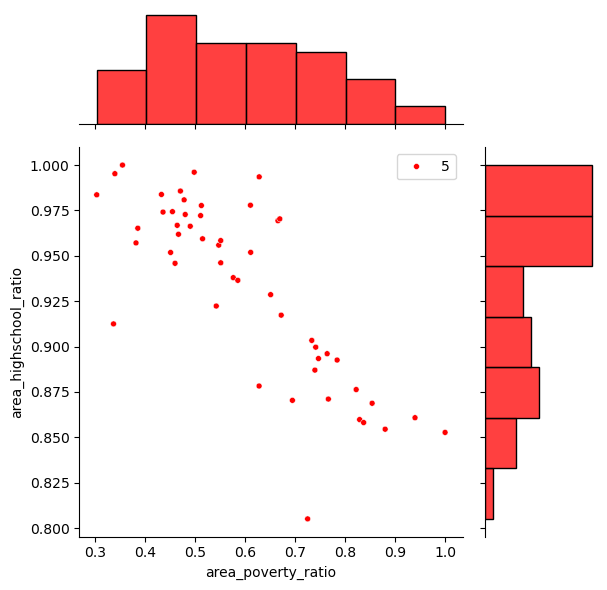

In [259]:
# you can change parameters of joint plot
# kind : { “scatter” | “reg” | “resid” | “kde” | “hex” }
# Different usage of parameters but same plot with previous one
g = sns.jointplot(x="area_poverty_ratio", y="area_highschool_ratio", data=data,size=5, ratio=3, color="r")
# size 5 ratio 3 yer kaplar diğer kısımlarda 1 1 
# yukardaki ile aynı işi yapar

In [261]:
# Soru 6 Öldürülen ınsanların ırklarının oranı

In [265]:
kill.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [267]:
kill.race.head(15)

0     A
1     W
2     H
3     W
4     H
5     W
6     H
7     W
8     W
9     B
10    W
11    B
12    B
13    W
14    B
Name: race, dtype: object

In [275]:
kill.race.value_counts()

race
W    1201
B     618
H     423
A      39
N      31
O      28
Name: count, dtype: int64

In [273]:
kill.race.value_counts().values # white .... other

array([1201,  618,  423,   39,   31,   28], dtype=int64)

In [277]:
kill.race.value_counts().index

Index(['W', 'B', 'H', 'A', 'N', 'O'], dtype='object', name='race')

In [279]:
# Race rates according in kill data 
kill.race.dropna(inplace = True) #Nan varsa drop et
labels = kill.race.value_counts().index
colors = ['grey','blue','red','yellow','green','brown'] # piechart renkleri
explode = [0,0,0,0,0,0] # piechart oranları
sizes = kill.race.value_counts().values

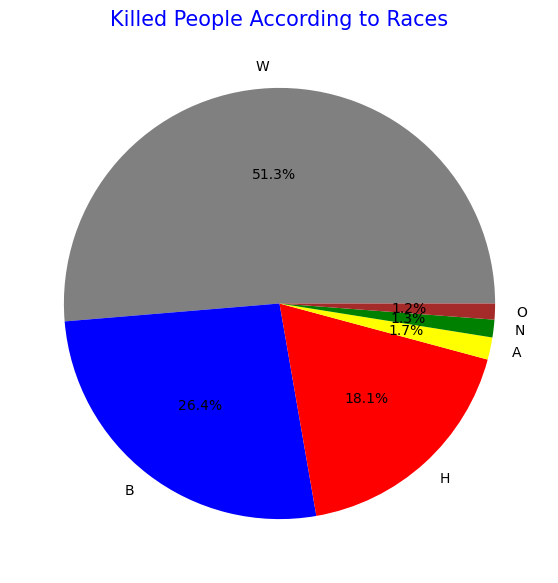

In [283]:
# visual
plt.figure(figsize = (7,7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Killed People According to Races',color = 'blue',fontsize = 15)
plt.show()

## Lm Plot

In [286]:
data.head()

,area_list,area_poverty_ratio,area_highschool_ratio
30,NJ,0.303558,0.983615
50,WY,0.337139,0.912479
6,CT,0.339883,0.995254
21,MA,0.355090,1.000000
20,MD,0.382097,0.957107


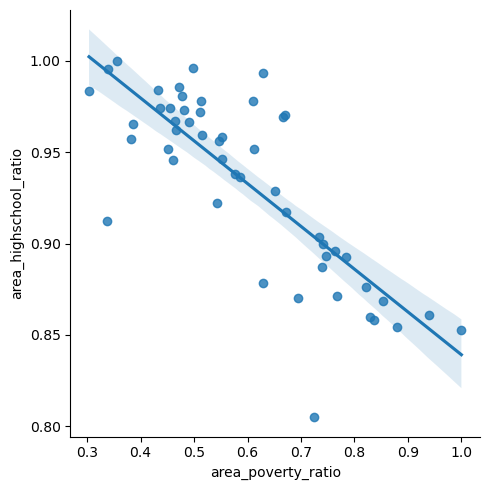

In [294]:
# Visualization of high school graduation rate vs Poverty rate of each state with different style of seaborn code
# lmplot 
# Show the results of a linear regression within each dataset
sns.lmplot(x="area_poverty_ratio", y="area_highschool_ratio", data=data)
plt.show()
#datanın içinden en optimum noktasından geçiyor. 
# fakirlik oranı 1 ise liseden mezun olma oranı nedir sorusunun ceavbı için linear regresyon yapılır ve en optimum çizgi çizilir
# y= 1-x gibi bir  denklem  ile ifade edilecek.


## Kde Plot

In [297]:
data.head()

,area_list,area_poverty_ratio,area_highschool_ratio
30,NJ,0.303558,0.983615
50,WY,0.337139,0.912479
6,CT,0.339883,0.995254
21,MA,0.355090,1.000000
20,MD,0.382097,0.957107


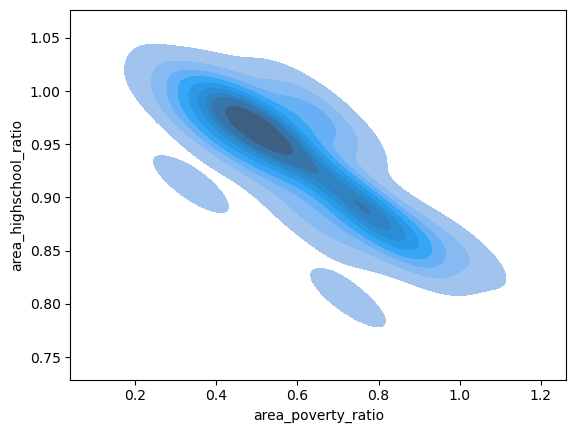

In [311]:
# Visualization of high school graduation rate vs Poverty rate of each state with different style of seaborn code
# cubehelix plot
sns.kdeplot(x="area_poverty_ratio", y="area_highschool_ratio",data=data ,shade=True, cut=3)
plt.show()
# shade : içinin dolu olup olmamasını etkiler
# cut : boyalı alanın büyüklüğünü ifade eder 3 te büyükken 30 da küçük

## Violin Plot

In [314]:
data.head()

,area_list,area_poverty_ratio,area_highschool_ratio
30,NJ,0.303558,0.983615
50,WY,0.337139,0.912479
6,CT,0.339883,0.995254
21,MA,0.355090,1.000000
20,MD,0.382097,0.957107


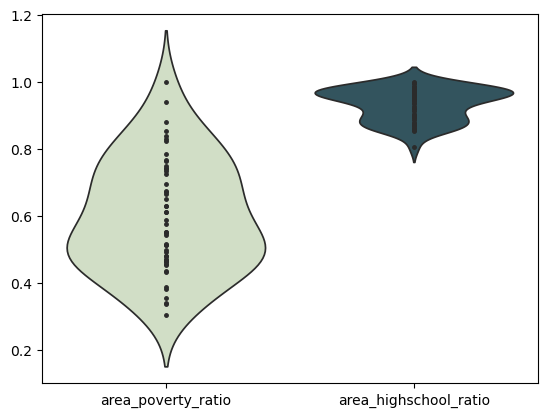

In [316]:
# Show each distribution with both violins and points
# Use cubehelix to get a custom sequential palette
pal = sns.cubehelix_palette(2, rot=-.5, dark=.3) # palet rengi veren kısım
sns.violinplot(data=data, palette=pal, inner="points") # points içinde gördüğümüz noktalar
plt.show()
# korealasyonu incelemiyor ayrı ayrı ne değerde olduğunu gösteriyor.
# 0.3 alt nokta mesela
#data içinde eyaletler de var ancak sayısal şeyleri görselleştirir sadece 
# en şişman olduğu yer 0.5 histogram da 0.5 en sık olduğu yerdi.
# ml ve istatistik de kullancaz.  meanlerine göre classification 


## Heatmap

In [329]:
data.head()

,area_list,area_poverty_ratio,area_highschool_ratio
30,NJ,0.303558,0.983615
50,WY,0.337139,0.912479
6,CT,0.339883,0.995254
21,MA,0.355090,1.000000
20,MD,0.382097,0.957107


In [323]:
# Sadece sayısal sütunlar arasındaki korelasyonu hesapla
corr = data.select_dtypes(include=['float64', 'int64']).corr()
print(corr)


                       area_poverty_ratio  area_highschool_ratio
area_poverty_ratio               1.000000              -0.805761
area_highschool_ratio           -0.805761               1.000000


In [331]:
# korealasyon sadece sayısal değerler arasında çıkar 

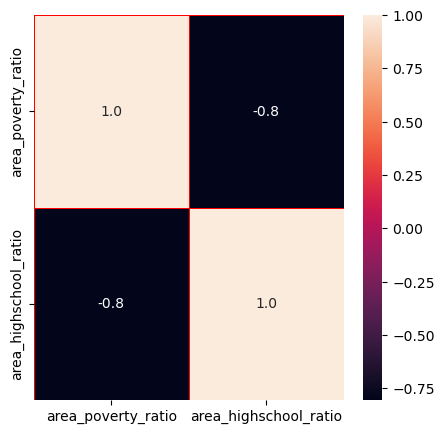

In [333]:
#correlation map
# Visualization of high school graduation rate vs Poverty rate of each state with different style of seaborn code
f,ax = plt.subplots(figsize=(5, 5)) # oluşturdupum plot içine heatmapi koyucam demek bu da
sns.heatmap(data.select_dtypes(include=['float64', 'int64']).corr(), annot=True, linewidths=0.5,linecolor="red", fmt= '.1f',ax=ax)
plt.show()
# heatmap data içinde korealasyonu ortaya çıkarmak için görselleştirmeler kllanılır.

## Box Plot

In [350]:
kill.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [352]:
kill.manner_of_death.unique()


array(['shot', 'shot and Tasered'], dtype=object)

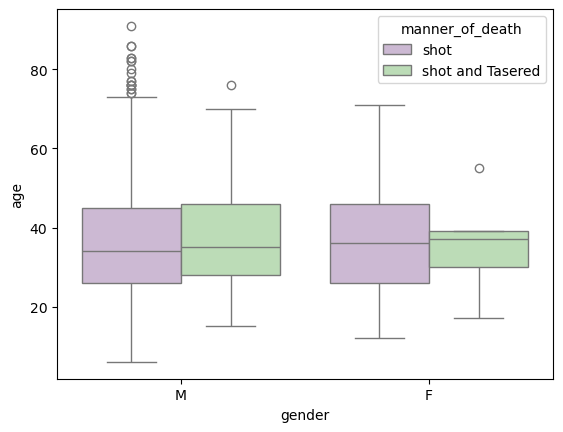

In [356]:
# manner of death(olum sekli) : ates edilerek, ates edilerek ve sok tabancasiyla
# gender cinsiyet
# age: yas
# Plot the orbital period with horizontal boxes
sns.boxplot(x="gender", y="age", hue="manner_of_death", data=kill, palette="PRGn")
plt.show() # data kill'e gider . Genderı bulur unique bulur.

In [362]:
# 3 farklı değişkeni tek plotta analiz edebiliyoruz bu şekilde
# üstteki outlier değerlerdir.
# çok sık kullanılan plotlardan biri istatistiksel  olarak güzel bilgiler verir.

## Swarm Plot

In [365]:
kill.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


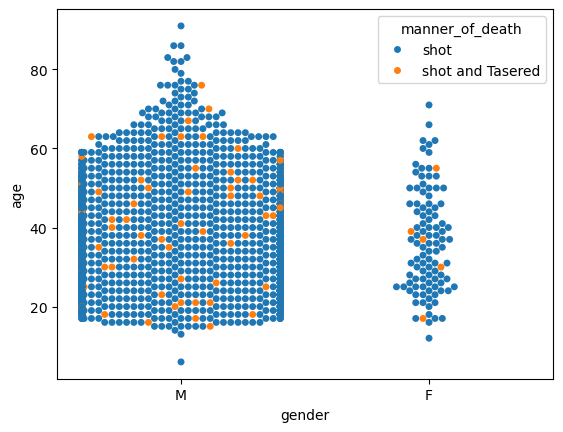

In [368]:
# swarm plot
# manner of death(olum sekli) : ates edilerek, ates edilerek ve sok tabancasiyla
# gender cinsiyet
# age: yas
sns.swarmplot(x="gender", y="age",hue="manner_of_death", data=kill)
plt.show()

In [372]:
# classıfıcatıon algoritmalarında kullanılırken bir datayı nasıl kullanacağımızı gösterir.
# data sayısı çok fazla ise swarm plot çizmek çok zor olur

## Pair Plot

In [375]:
data.head()

,area_list,area_poverty_ratio,area_highschool_ratio
30,NJ,0.303558,0.983615
50,WY,0.337139,0.912479
6,CT,0.339883,0.995254
21,MA,0.355090,1.000000
20,MD,0.382097,0.957107


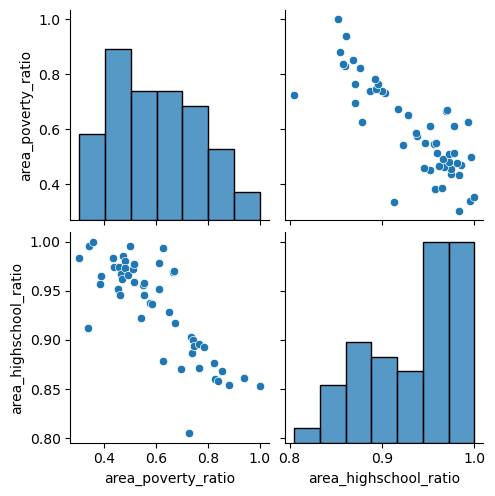

In [377]:
# pair plot
sns.pairplot(data)
plt.show()

## Count Plot

In [380]:
kill.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [382]:
kill.gender.value_counts()

gender
M    2428
F     107
Name: count, dtype: int64

In [388]:
kill.manner_of_death.value_counts()

manner_of_death
shot                2363
shot and Tasered     172
Name: count, dtype: int64

Text(0.5, 1.0, 'gender')

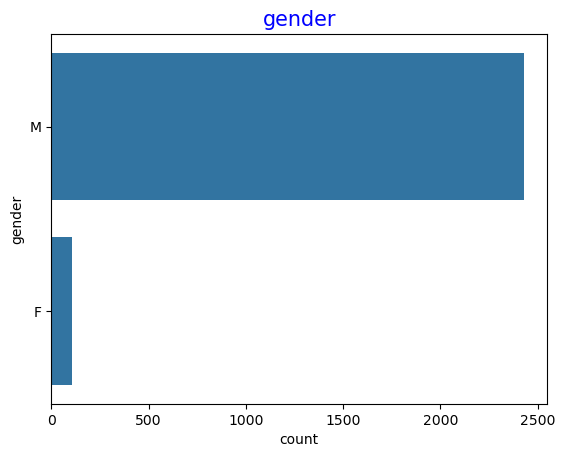

In [390]:
# kill properties
# Manner of death
sns.countplot(kill.gender)
#sns.countplot(kill.manner_of_death)
plt.title("gender",color = 'blue',fontsize=15)

Text(0.5, 1.0, 'gender')

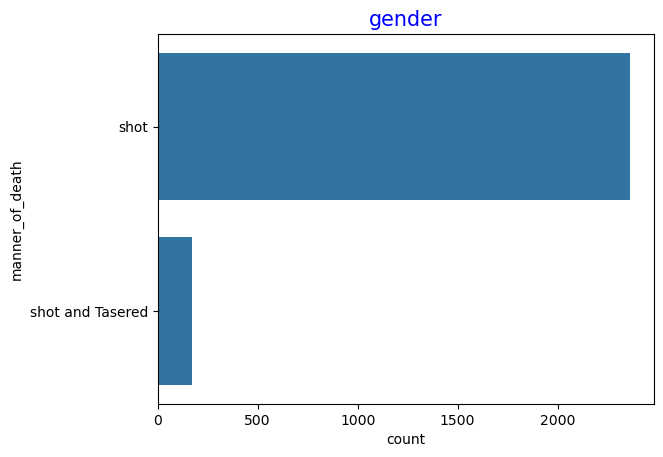

In [392]:
# kill properties
# Manner of death
#sns.countplot(kill.gender)
sns.countplot(kill.manner_of_death)
plt.title("gender",color = 'blue',fontsize=15)

Text(0.5, 1.0, 'Kill weapon')

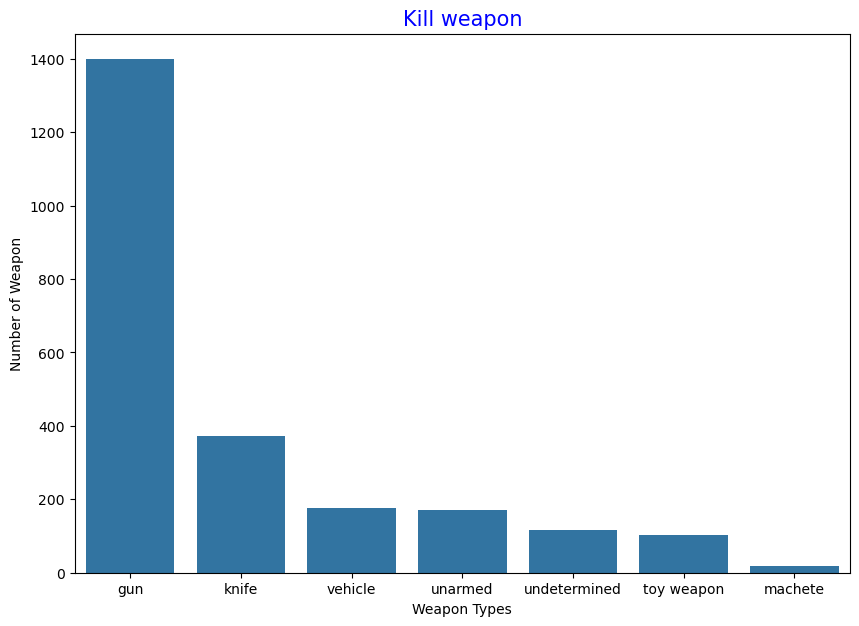

In [395]:
# kill weapon
armed = kill.armed.value_counts()
#print(armed)
plt.figure(figsize=(10,7))
sns.barplot(x=armed[:7].index,y=armed[:7].values)
plt.ylabel('Number of Weapon')
plt.xlabel('Weapon Types')
plt.title('Kill weapon',color = 'blue',fontsize=15)

Text(0.5, 1.0, 'Age of killed people')

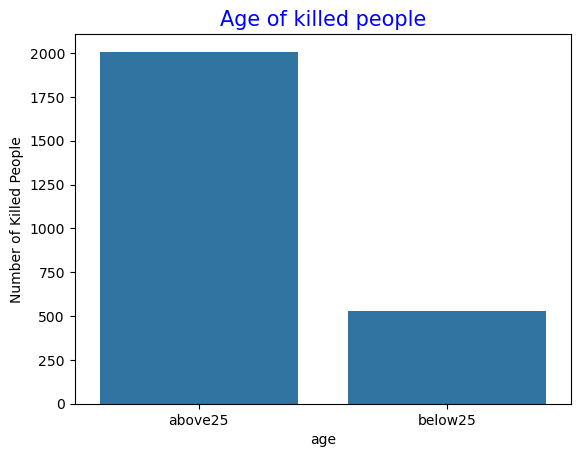

In [397]:
# age of killed people
above25 =['above25' if i >= 25 else 'below25' for i in kill.age]
df = pd.DataFrame({'age':above25})
sns.countplot(x=df.age)
plt.ylabel('Number of Killed People')
plt.title('Age of killed people',color = 'blue',fontsize=15)

Text(0.5, 1.0, 'Race of killed people')

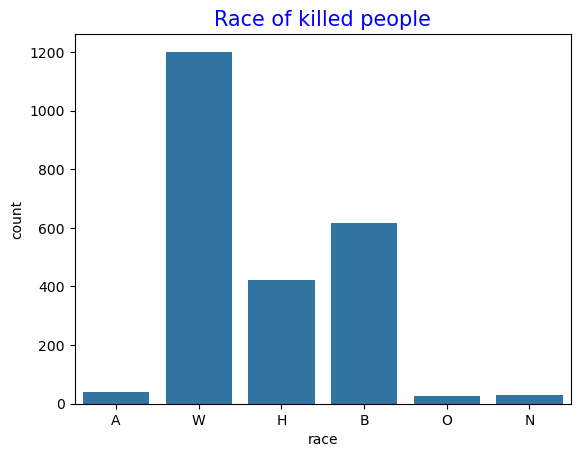

In [399]:
# Race of killed people
sns.countplot(data=kill, x='race')
plt.title('Race of killed people',color = 'blue',fontsize=15)

Text(0.5, 1.0, 'Most dangerous cities')

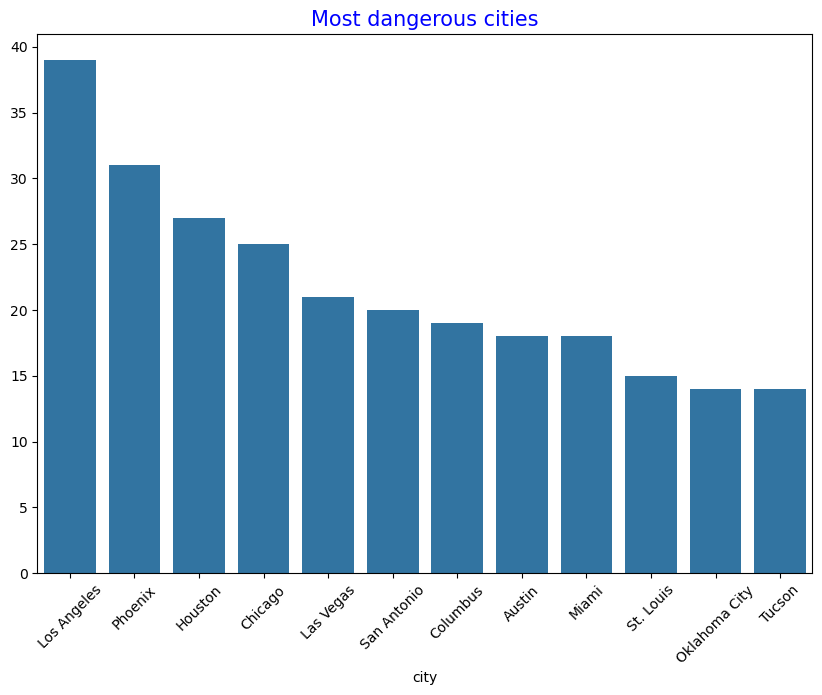

In [401]:
# Most dangerous cities
city = kill.city.value_counts()
plt.figure(figsize=(10,7))
sns.barplot(x=city[:12].index,y=city[:12].values)
plt.xticks(rotation=45)
plt.title('Most dangerous cities',color = 'blue',fontsize=15)

Text(0.5, 1.0, 'Most dangerous state')

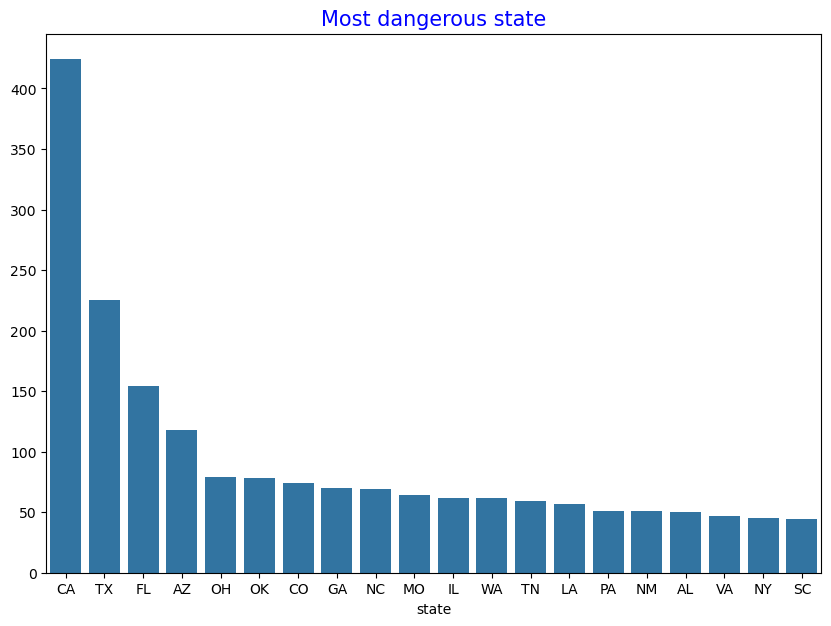

In [403]:
# most dangerous states
state = kill.state.value_counts()
plt.figure(figsize=(10,7))
sns.barplot(x=state[:20].index,y=state[:20].values)
plt.title('Most dangerous state',color = 'blue',fontsize=15)

Text(0.5, 1.0, 'Having mental illness or not')

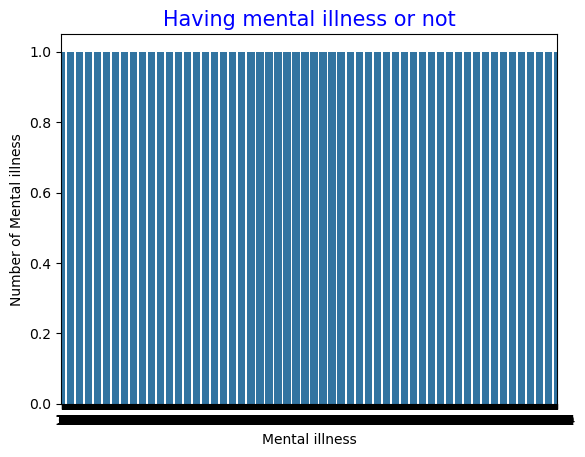

In [407]:
# Having mental ilness or not for killed people
sns.countplot(kill.signs_of_mental_illness)
plt.xlabel('Mental illness')
plt.ylabel('Number of Mental illness')
plt.title('Having mental illness or not',color = 'blue', fontsize = 15)

Text(0.5, 1.0, 'Threat types')

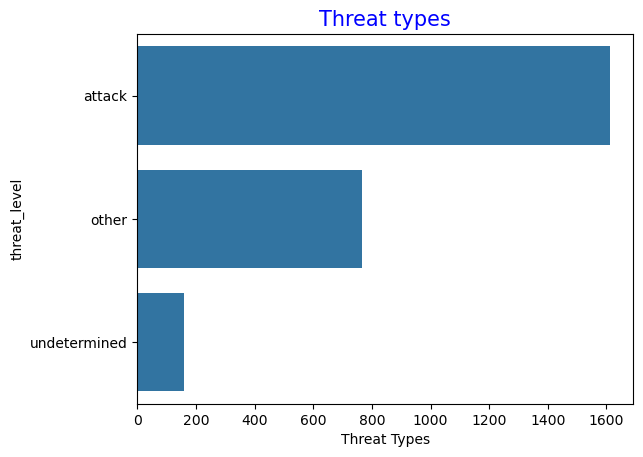

In [409]:
# Threat types
sns.countplot(kill.threat_level)
plt.xlabel('Threat Types')
plt.title('Threat types',color = 'blue', fontsize = 15)

Text(0.5, 1.0, 'Flee types')

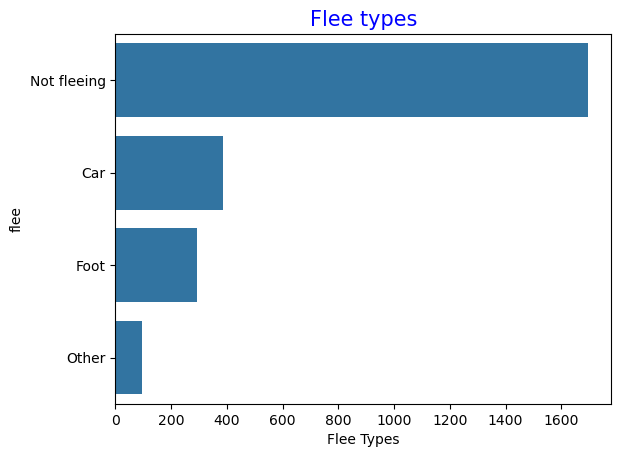

In [411]:
# Flee types
sns.countplot(kill.flee)
plt.xlabel('Flee Types')
plt.title('Flee types',color = 'blue', fontsize = 15)

Text(0.5, 1.0, 'Having body cameras or not on Police')

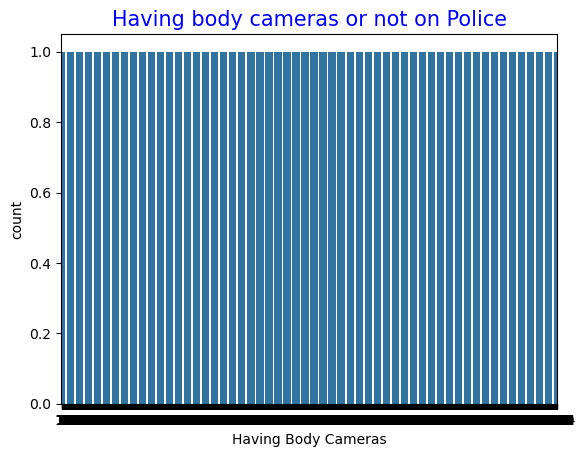

In [413]:
# Having body cameras or not for police
sns.countplot(kill.body_camera)
plt.xlabel('Having Body Cameras')
plt.title('Having body cameras or not on Police',color = 'blue',fontsize = 15)

Text(0.5, 1.0, 'Kill Numbers from States')

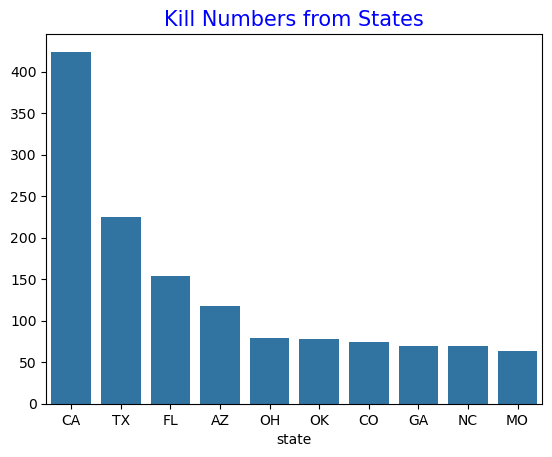

In [415]:
# Kill numbers from states in kill data
sta = kill.state.value_counts().index[:10]
sns.barplot(x=sta,y = kill.state.value_counts().values[:10])
plt.title('Kill Numbers from States',color = 'blue',fontsize=15)